# AutoML tools: PyCaret

In this notebook, we will explore a powerful AutoML library:
[**PyCaret**](https://pycaret.gitbook.io/docs).
[**PyCaret**](https://pycaret.gitbook.io/docs) provides a user-friendly interface for automating various steps in the machine learning workflow, making it easier for both beginners and experienced data scientists to build and evaluate machine learning models. 

We will be using this tool for regression (Boston dataset) and classification (Titanic dataset) problems.  
First, we install the library.

In [1]:
!pip install pycaret


[notice] A new release of pip is available: 24.0 -> 24.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install shap


[notice] A new release of pip is available: 24.0 -> 24.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
pip install pycaret[analysis]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 24.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd

df = pd.read_csv(r"C:\Users\mmartinovic\06-DataScienceMasterclass\bank-additional-full\bank-additional-full.csv", sep=";")

Before using AutoML tools, let's take a quick look at our dataset and its structure:

In [5]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [6]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [7]:
df.drop(["default", "duration"], axis=1, inplace=True)

In [14]:
### from sklearn.model_selection import train_test_split

X = df.drop('y', axis=1)
y = df['y']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 0)

## Regression with PyCaret

In [15]:
from pycaret.classification import *
 
s = setup(df, target = 'y')

,Description,Value
0,Session id,7814
1,Target,y
2,Target type,Binary
3,Target mapping,"no: 0, yes: 1"
4,Original data shape,"(41188, 19)"
5,Transformed data shape,"(41188, 59)"
6,Transformed train set shape,"(28831, 59)"
7,Transformed test set shape,"(12357, 59)"
8,Numeric features,9
9,Categorical features,9


Now that the data is preprocessed, we can use
[`compare_models()`](https://pycaret.gitbook.io/docs/get-started/functions/train#compare_models)
function, which trains and evaluates the performance of all the estimators.

In [16]:
best = compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.9002,0.7984,0.9002,0.8821,0.8810,0.3268,0.3662,0.3550
gbc,Gradient Boosting Classifier,0.8993,0.7991,0.8993,0.8805,0.8775,0.3003,0.3474,0.8160
ridge,Ridge Classifier,0.8990,0.7878,0.8990,0.8802,0.8743,0.2754,0.3322,0.1890
ada,Ada Boost Classifier,0.8990,0.7931,0.8990,0.8800,0.8755,0.2853,0.3376,0.4540
lr,Logistic Regression,0.8987,0.7889,0.8987,0.8794,0.8753,0.2840,0.3356,2.2110
xgboost,Extreme Gradient Boosting,0.8959,0.7796,0.8959,0.8762,0.8791,0.3253,0.3520,0.2710
rf,Random Forest Classifier,0.8922,0.7714,0.8922,0.8724,0.8771,0.3208,0.3406,0.6340
knn,K Neighbors Classifier,0.8906,0.7283,0.8906,0.8710,0.8763,0.3196,0.3367,0.7340
lda,Linear Discriminant Analysis,0.8903,0.7878,0.8903,0.8768,0.8817,0.3690,0.3763,0.2810
svm,SVM - Linear Kernel,0.8873,0.7572,0.8873,0.8492,0.8580,0.1897,0.2209,0.5310


With PyCaret we got very similar list of best regressors.

In [12]:
evaluate_model(best)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

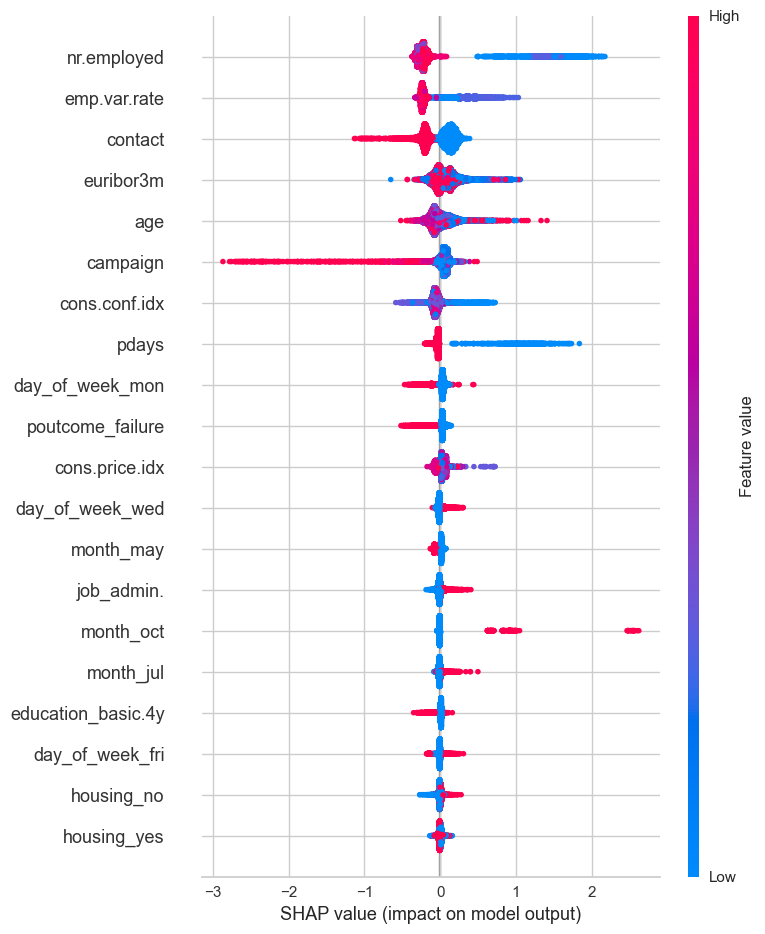

In [13]:
interpret_model(best)